<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/19_transfer_learning_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning

Training a deep learning model from scratch requires a large amount of labeled data and significant computational resources.

Transfer Learning is a technique where a model that has already been trained on a large dataset is reused for a new but related task.

Instead of learning everything from the beginning, the model starts with the knowledge it has already learned and adapts it to the new problem.

This reduces training time, improves performance on small datasets, and is widely used in real-world applications.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
    VGG16,
    EfficientNetB0
)

print("Available Models:")
print("- MobileNetV2")
print("- ResNet50")
print("- VGG16")
print("- EfficientNetB0")

Available Models:
- MobileNetV2
- ResNet50
- VGG16
- EfficientNetB0


In [ ]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.summary()

In [ ]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

In [ ]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])

model.summary()

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
print("Trainable Parameters:")

trainable = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

print(trainable)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Frozen Layers":[
        "Weights remain unchanged",
        "Faster training",
        "Less computation"
    ],

    "Trainable Layers":[
        "Weights updated",
        "Longer training",
        "Requires more data"
    ]

})

comparison

In [ ]:
models = pd.DataFrame({

    "Model":[
        "VGG16",
        "ResNet50",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Typical Use":[
        "Image Classification",
        "Deep CNN",
        "Mobile Devices",
        "Efficient Image Classification"
    ]

})

models

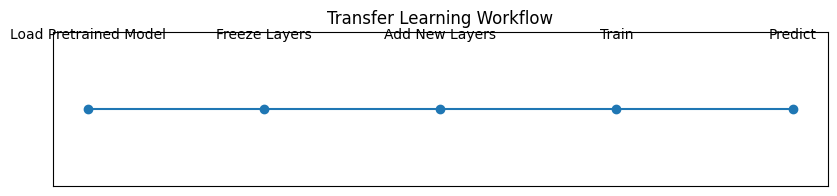

In [11]:
steps = [

    "Load Pretrained Model",

    "Freeze Layers",

    "Add New Layers",

    "Train",

    "Predict"

]

plt.figure(figsize=(10,2))

plt.plot(
    range(len(steps)),
    [1]*len(steps),
    marker="o"
)

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])

plt.yticks([])

plt.title("Transfer Learning Workflow")

plt.show()